In [26]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit.circuit.library import QFT

def int_to_bits(a, num_bits=None):
    bits = [(a >> i) & 1 for i in range(num_bits or a.bit_length())]
    return bits  # LSB first

def remove_leading_0s(bits):
    first_one = next((i for i, b in enumerate(bits) if b), len(bits))
    return bits[first_one:]

def add_classically_controlled_X(circuit, qs, bit):
    if bit:
        for q in qs:
            circuit.x(q)

def logical_and(qc, cq1, cq2, target):    
    qc.h(target)
    qc.t(target) 
    qc.cx(cq1, target) 
    qc.cx(cq2, target)
    qc.cx(target, cq1)
    qc.cx(target, cq2)
    qc.tdg(cq1) 
    qc.tdg(cq2)
    qc.t(target)
    qc.cx(target, cq1)
    qc.cx(target, cq2)
    qc.h(target)
    qc.s(target)
    
    return qc

def logical_and_dagger(qc, cq1, cq2, target):
    qc.sdg(target)
    qc.h(target)
    qc.cx(target, cq1)
    qc.cx(target, cq2)
    qc.t(cq1) 
    qc.t(cq2)
    qc.tdg(target)
    qc.cx(target, cq1)
    qc.cx(target, cq2) 
    qc.cx(cq2, target)
    qc.cx(cq1, target)
    qc.tdg(target)
    qc.h(target)
    
    return qc


def logical_and_uncompute(qc, cq1, cq2, target, clbit=None):
    if clbit is None:
        logical_and_dagger(qc, cq1, cq2, target)
        return
    
    qc.h(target)
    qc.measure(target, clbit)
    with qc.if_test((clbit, 1)):
        qc.cz(cq1, cq2)

    return qc


def addConstant(qubit_count, a, allow_measurement=True):
    if a == 0:
        return QuantumCircuit(qubit_count)
    
    a_bits = int_to_bits(a, num_bits=qubit_count)
    a_bits = remove_leading_0s(a_bits)
    bit_count = len(a_bits)
    offset = qubit_count - bit_count  # number of new LSB qubits to prepend

    if bit_count == 1:
        qc = QuantumCircuit(qubit_count)
        qc.x(qubit_count-1)
        return qc

    adderCircuit = addConstantClean(a_bits, bit_count, allow_measurement)

    # Build expanded circuit: full-width data register + same ancilla register
    new_data  = QuantumRegister(qubit_count, 'data')
    anc       = AncillaRegister(bit_count - 3, 'anc')
    qubit_map = [new_data[offset + i] for i in range(bit_count)] + list(anc)

    if allow_measurement:
        # Carry the single mid-circuit classical bit into the result circuit.
        # It lives in its own named register so it never collides with any
        # classical register added later (e.g. a final measurement register).
        mid    = ClassicalRegister(1, 'mid')
        result = QuantumCircuit(new_data, anc, mid,
                                name=f"+{int(''.join(map(str, a_bits)), 2)}")
        result.compose(adderCircuit, qubits=qubit_map, clbits=[mid[0]], inplace=True)
    else:
        result = QuantumCircuit(new_data, anc,
                                name=f"+{int(''.join(map(str, a_bits)), 2)}")
        result.compose(adderCircuit, qubits=qubit_map, inplace=True)

    return result

def addConstantClean(a_bits, qubit_count, allow_measurement):
    data = QuantumRegister(qubit_count, 'data')
    anc  = AncillaRegister(qubit_count - 3, 'anc')

    if allow_measurement:
        # One classical bit, reused by all four uncompute calls sequentially.
        mid   = ClassicalRegister(1, 'mid')
        qc    = QuantumCircuit(data, anc, mid,
                               name=f"+{int(''.join(map(str, a_bits)), 2)}")
        clbit = mid[0]
    else:
        qc    = QuantumCircuit(data, anc,
                               name=f"+{int(''.join(map(str, a_bits)), 2)}")
        clbit = None

    add_classically_controlled_X(qc, [data[0], data[1]], a_bits[1])
    logical_and(qc, data[0], data[1], anc[0])
    # qc.ccx(data[0], data[1], anc[0])

    add_classically_controlled_X(qc, [anc[0]], a_bits[1]^a_bits[2])
    add_classically_controlled_X(qc, [data[2]], a_bits[2])
    logical_and(qc, anc[0], data[2], anc[1])
    # qc.ccx(anc[0], data[2], anc[1])

    add_classically_controlled_X(qc, [anc[1]], a_bits[2]^a_bits[3])
    add_classically_controlled_X(qc, [data[3]], a_bits[3])
    logical_and(qc, anc[1], data[3], anc[2])
    # qc.ccx(anc[1], data[3], anc[2])

    add_classically_controlled_X(qc, [anc[2]], a_bits[3]^a_bits[4])
    add_classically_controlled_X(qc, [data[4]], a_bits[4])
    logical_and(qc, anc[2], data[4], anc[3])
    # qc.ccx(anc[2], data[4], anc[3])

    add_classically_controlled_X(qc, [anc[3]], a_bits[4]^a_bits[5])
    add_classically_controlled_X(qc, [data[5]], a_bits[5])
    qc.ccx(anc[3], data[5], data[6])

    add_classically_controlled_X(qc, [anc[3]], a_bits[5])

    qc.cx(anc[3], data[5])
    add_classically_controlled_X(qc, [anc[3]], a_bits[4])

    logical_and_uncompute(qc, anc[2], data[4], anc[3], clbit)
    # qc.ccx(anc[2], data[4], anc[3])
    add_classically_controlled_X(qc, [anc[2]], a_bits[4])

    qc.cx(anc[2], data[4])
    add_classically_controlled_X(qc, [anc[2]], a_bits[3])

    logical_and_uncompute(qc, anc[1], data[3], anc[2], clbit)
    # qc.ccx(anc[1], data[3], anc[2])
    add_classically_controlled_X(qc, [anc[1]], a_bits[3])

    qc.cx(anc[1], data[3])
    add_classically_controlled_X(qc, [anc[1]], a_bits[2])

    logical_and_uncompute(qc, anc[0], data[2], anc[1], clbit)
    # qc.ccx(anc[0], data[2], anc[1])
    add_classically_controlled_X(qc, [anc[0]], a_bits[2])

    qc.cx(anc[0], data[2])
    add_classically_controlled_X(qc, [anc[0]], a_bits[1])

    logical_and_uncompute(qc, data[0], data[1], anc[0], clbit)
    # qc.ccx(data[0], data[1], anc[0])
    add_classically_controlled_X(qc, [data[0]], a_bits[0])

    qc.cx(data[0], data[1])

    qc.x(data[0])
    add_classically_controlled_X(qc, [data[6]], a_bits[5]^a_bits[6])

    return qc


def addConstant_dagger(qubit_count, a):
    return addConstant(qubit_count, a, allow_measurement=False).inverse()

def add_constant_qft(n_qubits: int, c: int, ommitLastQft: bool) -> QuantumCircuit:
    """Returns a circuit that maps |x⟩ → |(x + c) mod 2^n⟩."""
    qc = QuantumCircuit(n_qubits, name=f"+{c}")
    qc.append(QFT(n_qubits, do_swaps=False), range(n_qubits))
    for k in range(n_qubits):
        angle = 2 * np.pi * c / (2 ** (k + 1))
        qc.p(angle, k)          # P(θ)|0⟩=|0⟩, P(θ)|1⟩=e^{iθ}|1⟩

    if not ommitLastQft:
        qc.append(QFT(n_qubits, do_swaps=False, inverse=True), range(n_qubits))

    return qc

def add_constant_qft_dagger(n_qubits: int, c: int, ommitFirstQft: bool = False) -> QuantumCircuit:
    qc = QuantumCircuit(n_qubits, name=f"+{c}")
    if not ommitFirstQft:
        qc.append(QFT(n_qubits, do_swaps=False), range(n_qubits))
    for k in range(n_qubits):
        angle = -2 * np.pi * c / (2 ** (k + 1))
        qc.p(angle, k)          # P(θ)|0⟩=|0⟩, P(θ)|1⟩=e^{iθ}|1⟩

    qc.append(QFT(n_qubits, do_swaps=False, inverse=True), range(n_qubits))
    
    return qc

def prepare_sto_state(n_qubits: int, a: float) -> QuantumCircuit:
    """Returns a circuit that prepares the state |ψ⟩ = N · Σ e^(-a·|i|) |i⟩."""
    qc = QuantumCircuit(n_qubits)
    last_qubit = n_qubits - 1

    qc.h(last_qubit)

    b = a
    for i in range(n_qubits-1):
        theta = 2 * np.arctan(np.exp(b))
        qc.cry(theta, last_qubit, i)
        b = b * 2
    qc.x(last_qubit)

    b = a
    for i in range(n_qubits-1):
        theta = 2 * np.arctan(np.exp(-b))
        qc.cry(theta, last_qubit, i)
        b = b * 2

    qc.x(last_qubit)

    return qc

def prepare_sto_state_dagger(n_qubits: int, a: float) -> QuantumCircuit:
    """Returns the adjoint of prepare_sto_state."""
    qc = QuantumCircuit(n_qubits)
    last_qubit = n_qubits - 1

    qc.x(last_qubit)

    b = a
    for i in range(n_qubits-1):
        theta = 2 * np.arctan(np.exp(-b))
        qc.cry(-theta, last_qubit, i)
        b = b * 2
        
    qc.x(last_qubit)

    b = a
    for i in range(n_qubits-1):
        theta = 2 * np.arctan(np.exp(b))
        qc.cry(-theta, last_qubit, i)
        b = b * 2

    qc.h(last_qubit)
    return qc


def sto(n_qubits: int, a: float, center: int) -> QuantumCircuit:
    """Returns a circuit that prepares the state |ψ⟩ = N · Σ e^(-a·|i-center|) |i⟩.
    The returned circuit has n_qubits data qubits followed by the ancilla qubits
    required by addConstant (all initialised and returned to |0⟩)."""
    adder   = addConstant(n_qubits, center)
    n_total = adder.num_qubits   # data + ancilla

    # Inherit the full register layout from the adder (quantum + any classical
    # 'mid' register used by mid-circuit measurement-based uncompute).
    qc = QuantumCircuit(*adder.qregs, *adder.cregs)
    # State preparation acts only on the data qubits (first n_qubits)
    qc.compose(prepare_sto_state(n_qubits, a), qubits=list(range(n_qubits)), inplace=True)
    # Adder acts on all qubits (and classical bits) — registers match exactly
    qc.compose(adder, inplace=True)

    return qc


def sto_dagger(n_qubits: int, a: float, center: int) -> QuantumCircuit:
    """Returns the adjoint of sto.
    The returned circuit has n_qubits data qubits followed by the ancilla qubits
    required by addConstant_dagger (all initialised and returned to |0⟩)."""
    adder_dag = addConstant_dagger(n_qubits, center)
    n_total   = adder_dag.num_qubits
    n_anc     = n_total - n_qubits

    qc = QuantumCircuit(n_total)
    # Inverse adder acts on all qubits first
    qc.compose(adder_dag, qubits=list(range(n_total)), inplace=True)
    # Inverse state preparation acts only on the data qubits
    qc.compose(prepare_sto_state_dagger(n_qubits, a), qubits=list(range(n_qubits)), inplace=True)

    return qc


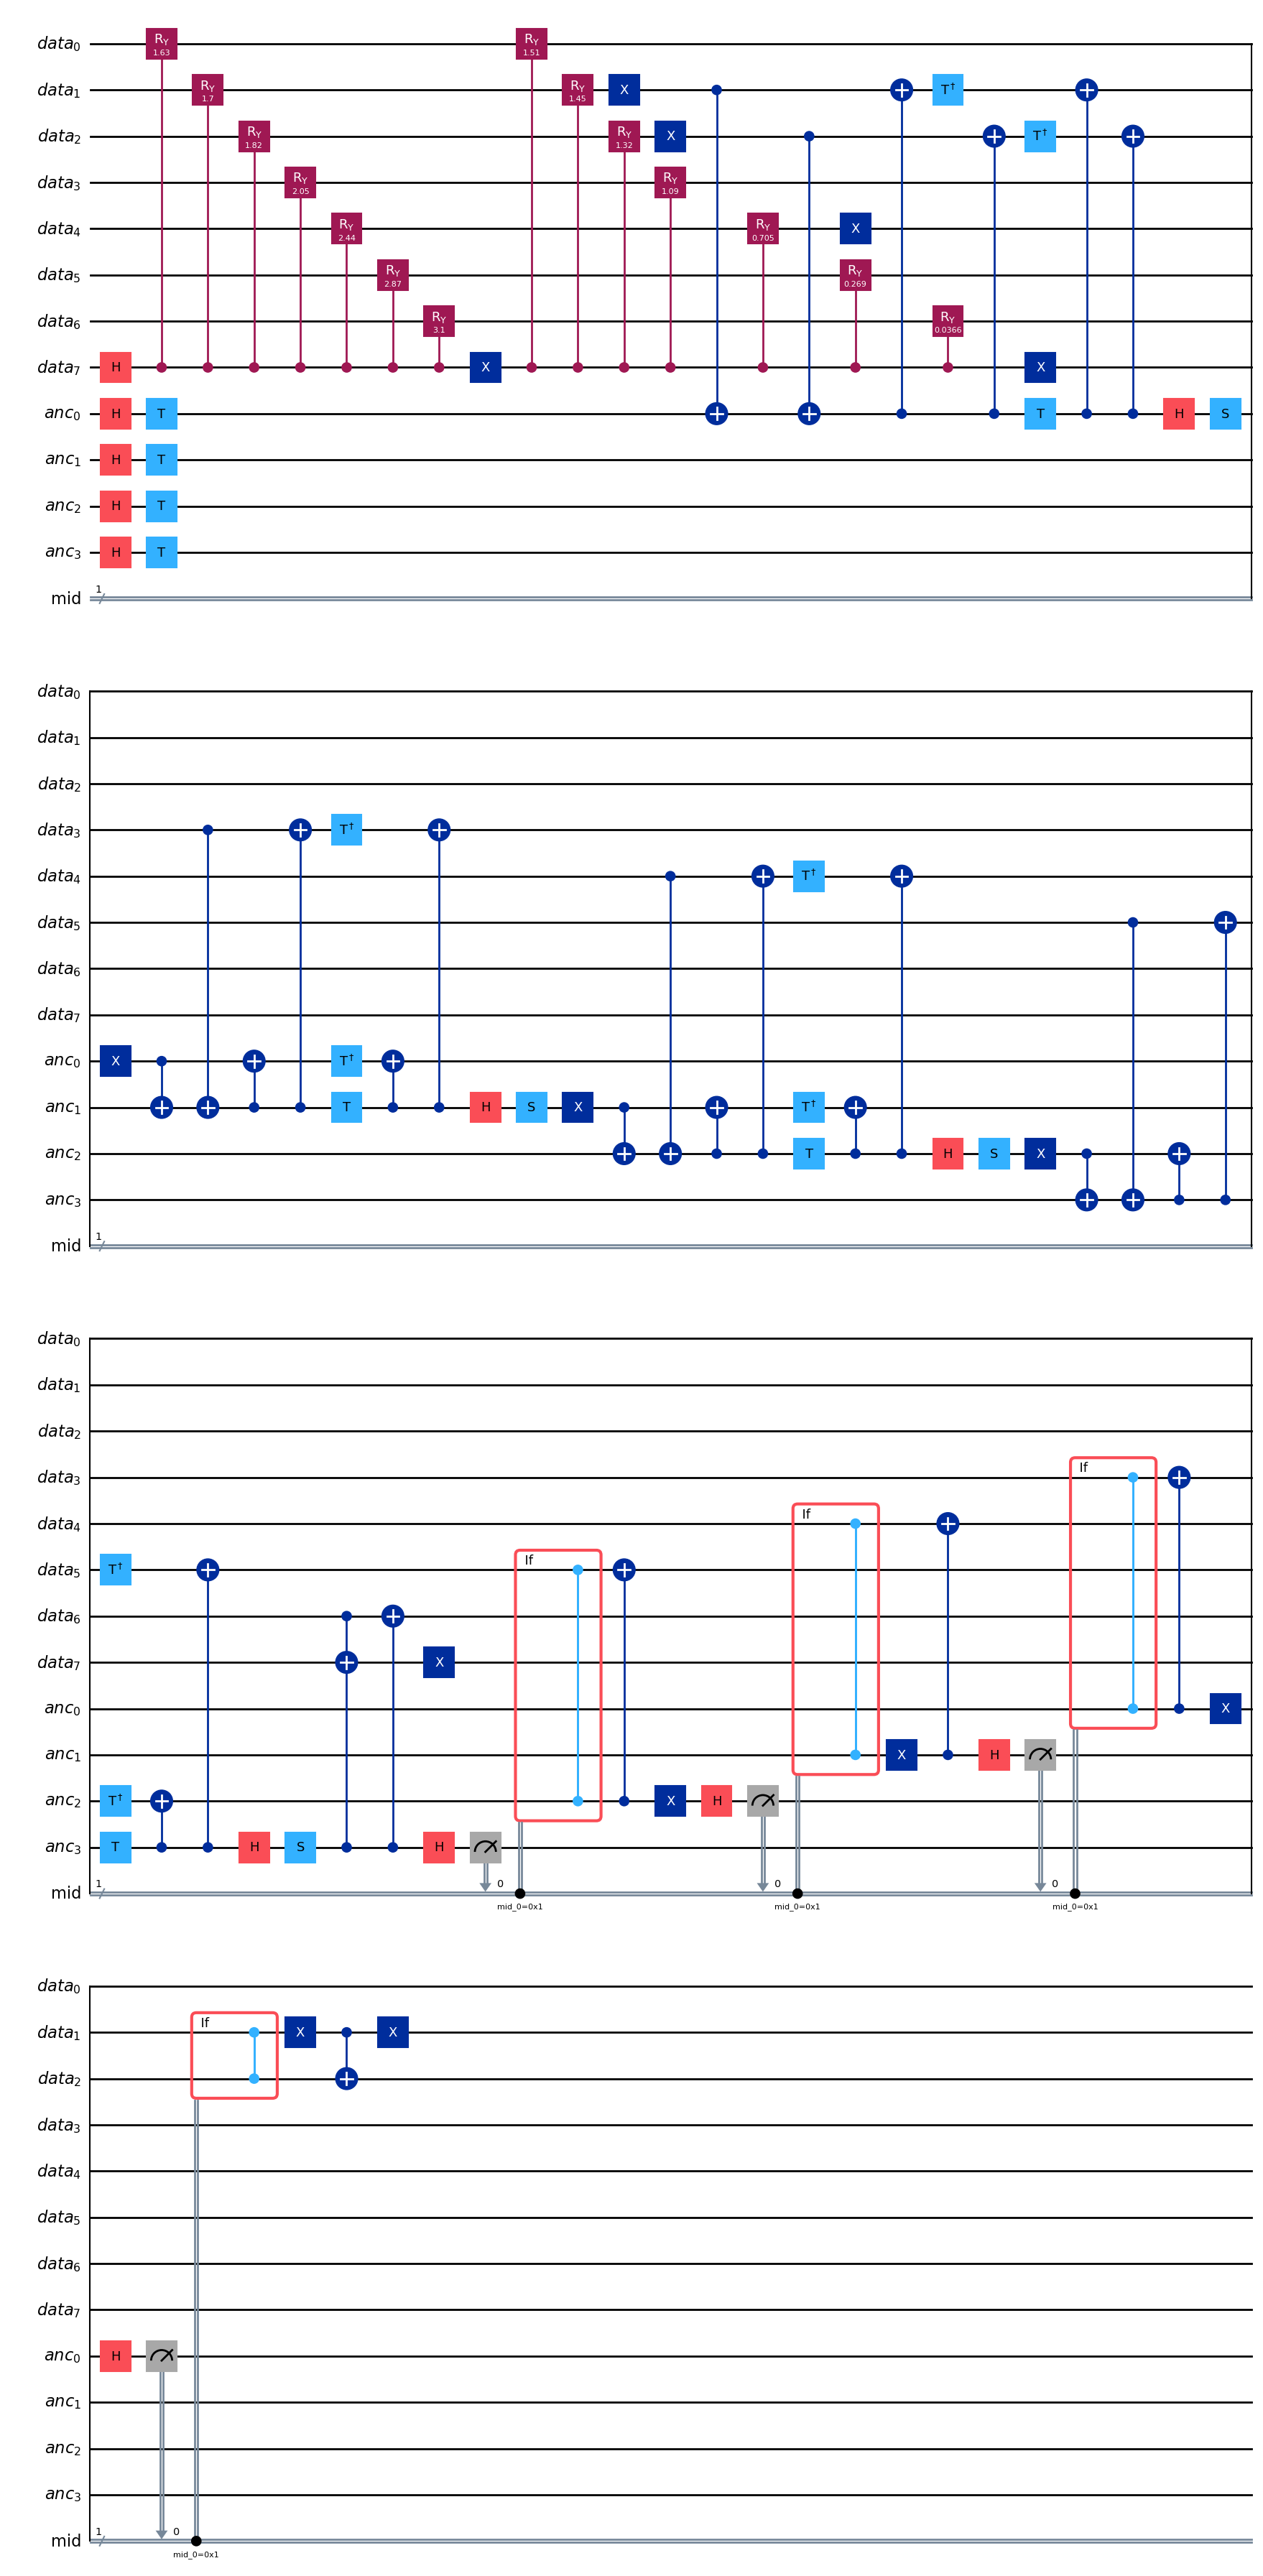

In [27]:
# Decaying exponential state: |ψ⟩ = N · Σ e^(-a·i) |i⟩  for i = 0 … 2^4-1
a = 1  # decay constant
n_qubits = 8
max_range = 16

scale = max_range / (2 ** n_qubits)
scaled_a = a * scale

center1 = 2 ** (n_qubits - 1)
center2 = 2 ** (n_qubits - 1) + 22

qc = sto(n_qubits, scaled_a, center2)
# qc.compose(sto_dagger(n_qubits, scaled_a, center2), inplace=True)

qc.draw('mpl', style='iqp')

# print(center1)
# print(center2)

In [30]:
from qiskit_aer import AerSimulator
from utils.statevector_viz import get_data_amplitudes, print_statevector

data_amps = get_data_amplitudes(qc, n_qubits)
print_statevector(data_amps, n_qubits)


Statevector amplitudes (|basis⟩ : amplitude):
  |00000000⟩ : 0.0003-0.0000j  (prob = 0.0000)
  |00000001⟩ : 0.0003-0.0000j  (prob = 0.0000)
  |00000010⟩ : 0.0003-0.0000j  (prob = 0.0000)
  |00000011⟩ : 0.0003-0.0000j  (prob = 0.0000)
  |00000100⟩ : 0.0003-0.0000j  (prob = 0.0000)
  |00000101⟩ : 0.0002-0.0000j  (prob = 0.0000)
  |00000110⟩ : 0.0002-0.0000j  (prob = 0.0000)
  |00000111⟩ : 0.0002-0.0000j  (prob = 0.0000)
  |00001000⟩ : 0.0002-0.0000j  (prob = 0.0000)
  |00001001⟩ : 0.0002-0.0000j  (prob = 0.0000)
  |00001010⟩ : 0.0002-0.0000j  (prob = 0.0000)
  |00001011⟩ : 0.0002+0.0000j  (prob = 0.0000)
  |00001100⟩ : 0.0002-0.0000j  (prob = 0.0000)
  |00001101⟩ : 0.0001-0.0000j  (prob = 0.0000)
  |00001110⟩ : 0.0001-0.0000j  (prob = 0.0000)
  |00001111⟩ : 0.0001-0.0000j  (prob = 0.0000)
  |00010000⟩ : 0.0001-0.0000j  (prob = 0.0000)
  |00010001⟩ : 0.0001+0.0000j  (prob = 0.0000)
  |00010010⟩ : 0.0001-0.0000j  (prob = 0.0000)
  |00010011⟩ : 0.0001+0.0000j  (prob = 0.0000)
  |00010100⟩ :

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


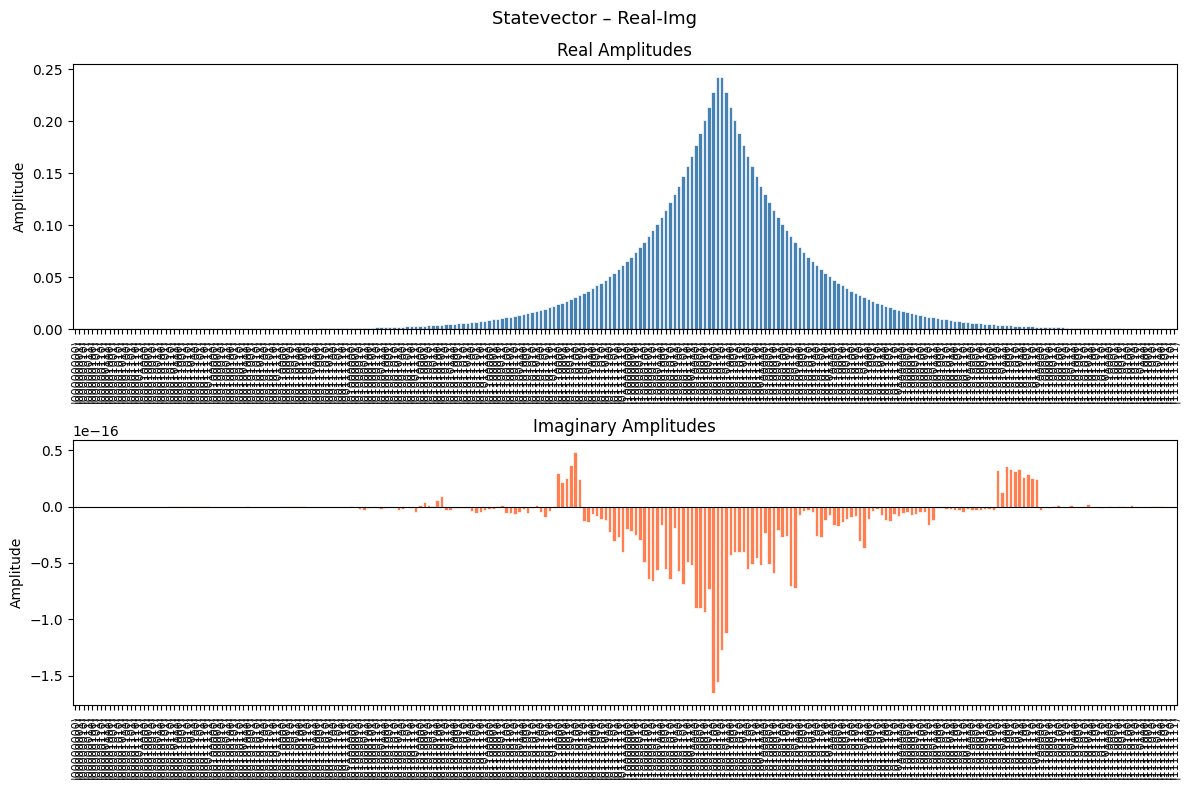

In [31]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
workspace_root = str(Path.cwd().parent)
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

from utils.statevector_viz import plot_statevector_real_imag

fig = plot_statevector_real_imag(data_amps, n_qubits)


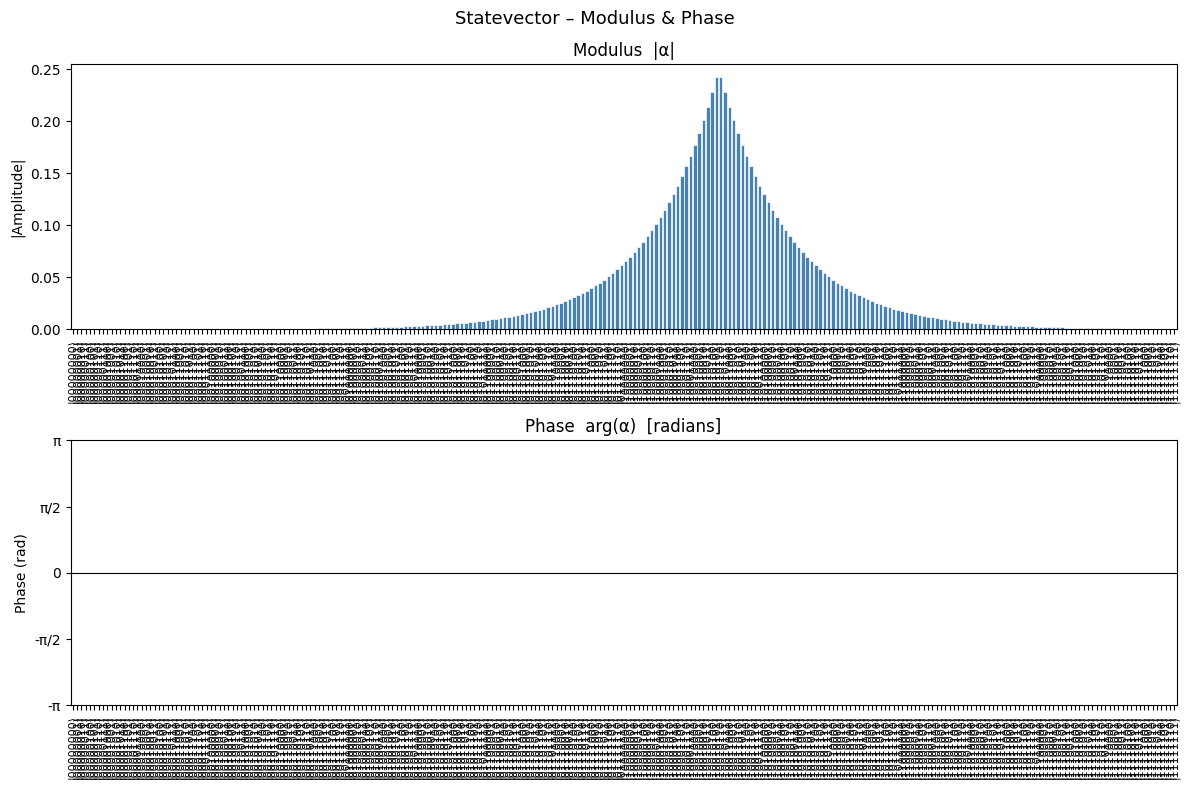

In [23]:
import importlib, utils.statevector_viz as _sv_mod
importlib.reload(_sv_mod)
from utils.statevector_viz import plot_statevector_modulus_phase

# Visualize statevector: modulus and phase stacked vertically
fig = plot_statevector_modulus_phase(data_amps, n_qubits)


Measurement results (1024 shots):
  |00000000⟩ :    0  
  |00000001⟩ :    0  
  |00000010⟩ :    0  
  |00000011⟩ :    0  
  |00000100⟩ :    0  
  |00000101⟩ :    0  
  |00000110⟩ :    0  
  |00000111⟩ :    0  
  |00001000⟩ :    0  
  |00001001⟩ :    0  
  |00001010⟩ :    0  
  |00001011⟩ :    0  
  |00001100⟩ :    0  
  |00001101⟩ :    0  
  |00001110⟩ :    0  
  |00001111⟩ :    0  
  |00010000⟩ :    0  
  |00010001⟩ :    0  
  |00010010⟩ :    0  
  |00010011⟩ :    0  
  |00010100⟩ :    0  
  |00010101⟩ :    0  
  |00010110⟩ :    0  
  |00010111⟩ :    0  
  |00011000⟩ :    0  
  |00011001⟩ :    0  
  |00011010⟩ :    0  
  |00011011⟩ :    0  
  |00011100⟩ :    0  
  |00011101⟩ :    0  
  |00011110⟩ :    0  
  |00011111⟩ :    0  
  |00100000⟩ :    0  
  |00100001⟩ :    0  
  |00100010⟩ :    0  
  |00100011⟩ :    0  
  |00100100⟩ :    0  
  |00100101⟩ :    0  
  |00100110⟩ :    0  
  |00100111⟩ :    0  
  |00101000⟩ :    0  
  |00101001⟩ :    0  
  |00101010⟩ :    0  
  |00101011⟩ :    0 

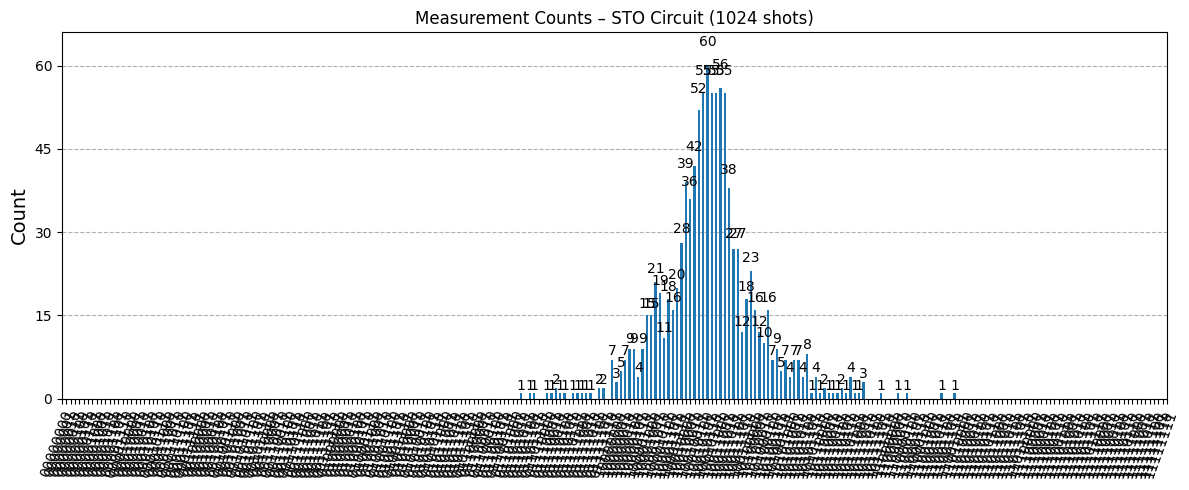

In [33]:
from utils.statevector_viz import sample_measurement_counts, print_measurement_counts

shots = 1024
counts = sample_measurement_counts(qc, n_qubits, shots=shots)
print_measurement_counts(counts, shots)

# Plot histogram of sample counts
fig = plot_histogram(
    counts,
    title=f"Measurement Counts – STO Circuit ({shots} shots)",
    figsize=(12, 5),
    bar_labels=True,
)
fig.tight_layout()
display(fig)


In [101]:
# ── Overlap circuit:  O₂† · O₁ · |0⟩ ────────────────────────────────────────
# S = ⟨ψ₁|ψ₂⟩ = ⟨0|O₁†O₂|0⟩  ⟹  circuit = O₁† O₂ (or equivalently O₂† O₁)
# P(|0…0⟩) = |S|²   →   S = √P  (real, positive wavefunctions)

# center1 effective max is at index 127.5  → physical position 127.5 * dx = 7.96875
# center2 = 150: effective max at 149.5    → physical position 149.5 * dx = 9.34375
# separation d = (149.5 - 127.5) * dx = 22 * (1/16) = 1.375 a.u.  ≈ 1.4 a.u.

center2_overlap = 150
d_grid  = (149.5 - 127.5) * scale          # effective physical separation
S_cont  = (1 + a * d_grid) * np.exp(-a * d_grid)   # continuous benchmark

# qc_sto uses mid-circuit measurement-based uncompute and carries a 'mid'
# classical register.  sto_dagger is fully unitary (uses .inverse()).
qc_sto     = sto(n_qubits, scaled_a, center2_overlap)
qc_sto_dag = sto_dagger(n_qubits, scaled_a, center1)
n_ov_total = max(qc_sto.num_qubits, qc_sto_dag.num_qubits)
n_anc_ov   = n_ov_total - n_qubits

# Build the overlap circuit.  qc_sto carries a 'mid' classical register, so
# we add it explicitly and map clbits during compose.
mid_ov = ClassicalRegister(1, 'mid')
qc_overlap = QuantumCircuit(n_ov_total)
qc_overlap.add_register(mid_ov)
qc_overlap.compose(qc_sto,     qubits=list(range(qc_sto.num_qubits)),
                   clbits=[mid_ov[0]], inplace=True)
qc_overlap.compose(qc_sto_dag, qubits=list(range(qc_sto_dag.num_qubits)), inplace=True)

zero_key_ov = '0' * n_qubits

# ── Exact overlap via Aer statevector (ground truth) ──────────────────────────
# After mid-circuit measurements the ancilla qubits collapse to a definite
# classical state (not necessarily |0⟩), just as in cell 3.  We must use the
# same reshape trick: find the dominant ancilla block and extract the data-|0⟩
# amplitude from it.
qc_ov_sv = qc_overlap.copy()
qc_ov_sv.save_statevector()
sv_ov = np.array(sim.run(qc_ov_sv, shots=1).result().get_statevector())

if n_anc_ov > 0:
    sv_ov_blocks  = sv_ov.reshape(2**n_anc_ov, 2**n_qubits)
    block_norms   = np.sum(np.abs(sv_ov_blocks)**2, axis=1)
    anc_idx       = np.argmax(block_norms)
    S_exact = sv_ov_blocks[anc_idx, 0].real   # data |0…0⟩ in dominant ancilla block
    P_exact = abs(sv_ov_blocks[anc_idx, 0]) ** 2
else:
    S_exact = sv_ov[0].real
    P_exact = abs(sv_ov[0]) ** 2

print(f"Effective separation    d  = {d_grid:.4f} a.u.  (closest to 1.4 a.u.)")
print(f"Continuous benchmark    S  = {S_cont:.6f}")
print()
print(f"Exact (Aer statevector) amplitude  ⟨0|circuit|0⟩ = {S_exact:.6f}")
print(f"Exact (Aer statevector) |S|²       P(|0…0⟩)      = {P_exact:.6f}")
print(f"Exact S = √P                                      = {np.sqrt(P_exact):.6f}")
print()

# ── Sampler estimation via Aer shot-based simulation ─────────────────────────
# Add a dedicated 'meas_ov' register so we can extract just the data qubit bits
# from the space-separated multi-register bitstring Aer returns.
shots = 8192
qc_ov_sample = qc_overlap.copy()
meas_ov_reg = ClassicalRegister(n_qubits, 'meas_ov')
qc_ov_sample.add_register(meas_ov_reg)
qc_ov_sample.measure(list(range(n_qubits)), meas_ov_reg)

raw_ov = sim.run(qc_ov_sample, shots=shots).result().get_counts()

# Bitstring format: 'meas_ov_bits mid_bit'  ('meas_ov' added last → leftmost token)
zero_count = sum(c for bs, c in raw_ov.items() if bs.split()[0] == zero_key_ov)
p_zero_sampled = zero_count / shots
S_sampled = np.sqrt(p_zero_sampled)

print(f"Sampler ({shots} shots):")
print(f"  Counts for |{zero_key_ov}⟩  = {zero_count}")
print(f"  P(|0…0⟩)  = {p_zero_sampled:.6f}")
print(f"  S = √P    = {S_sampled:.6f}")
print()
print(f"Error vs continuous:  {abs(S_sampled - S_cont):.4f}  ({abs(S_sampled - S_cont)/S_cont*100:.2f} %)")
print(f"Discretisation error: {abs(S_exact  - S_cont):.4f}  ({abs(S_exact  - S_cont)/S_cont*100:.2f} %)")
print(f"Shot noise:           {abs(S_sampled - S_exact):.4f}  ({abs(S_sampled - S_exact)/S_exact*100:.2f} %)")


Effective separation    d  = 1.3750 a.u.  (closest to 1.4 a.u.)
Continuous benchmark    S  = 0.600494

Exact (Aer statevector) amplitude  ⟨0|circuit|0⟩ = 0.600721
Exact (Aer statevector) |S|²       P(|0…0⟩)      = 0.360865
Exact S = √P                                      = 0.600721

Sampler (8192 shots):
  Counts for |00000000⟩  = 2938
  P(|0…0⟩)  = 0.358643
  S = √P    = 0.598868

Error vs continuous:  0.0016  (0.27 %)
Discretisation error: 0.0002  (0.04 %)
Shot noise:           0.0019  (0.31 %)


=== Logical circuit ===
Qubits              : 12
Depth               : 90
Gate counts         : {'cx': 29, 'cry': 28, 'x': 17, 'h': 14, 'measure': 12, 't': 8, 'tdg': 8, 's': 4, 'if_else': 4, 'ccx': 1}

=== After transpilation to IBM native gates (no connectivity constraint) ===
Depth               : 291
Gate counts         : {'rz': 223, 'sx': 106, 'ecr': 87, 'x': 61, 'measure': 12, 'if_else': 4}
2-qubit gates (ECR) : 87

=== Feasibility summary ===
ECR count           : 87
Est. fidelity       : (1 - 0.003)^87 = 0.7700
Verdict             : feasible ✓


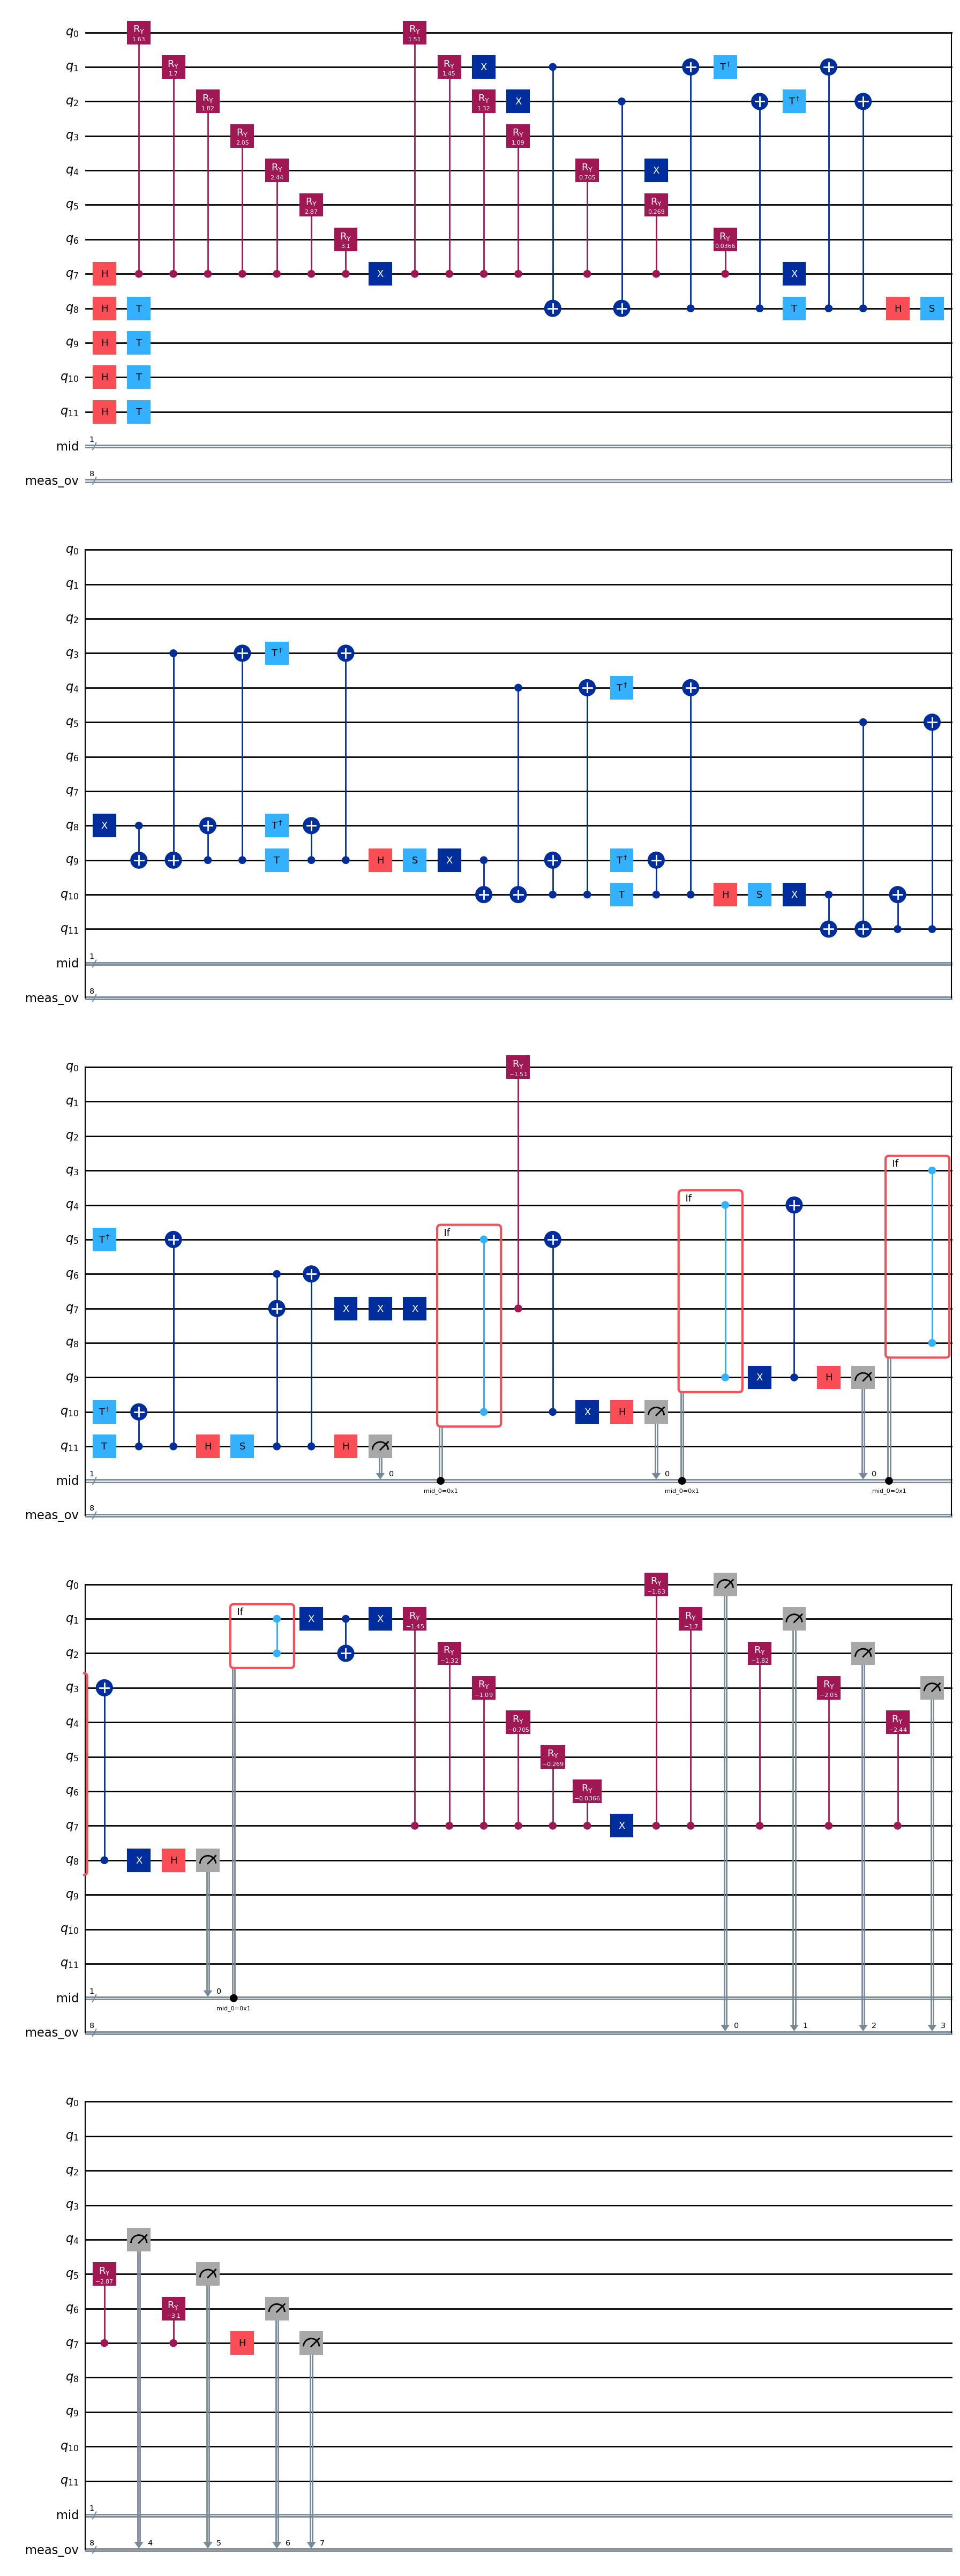

In [102]:
from qiskit.compiler import transpile

# ── Circuit complexity (logical) ───────────────────────────────────────────────

print("=== Logical circuit ===")
print(f"Qubits              : {qc_ov_sample.num_qubits}")
print(f"Depth               : {qc_ov_sample.depth()}")
print(f"Gate counts         : {dict(qc_ov_sample.count_ops())}")

# ── Transpile to IBM's native gate set (basis: ECR, RZ, SX, X) ────────────────
# Using 'ibm_torino' topology as a representative 133-qubit Heron r1 device.
# optimization_level=3 = most aggressive optimisation Qiskit can do.
qc_t = transpile(qc_ov_sample, basis_gates=['ecr', 'rz', 'sx', 'x'],
                 optimization_level=3, seed_transpiler=42)

two_q = {k: v for k, v in qc_t.count_ops().items() if k == 'ecr'}
print()
print("=== After transpilation to IBM native gates (no connectivity constraint) ===")
print(f"Depth               : {qc_t.depth()}")
print(f"Gate counts         : {dict(qc_t.count_ops())}")
print(f"2-qubit gates (ECR) : {two_q.get('ecr', 0)}")
print()
print("=== Feasibility summary ===")
ecr_count = two_q.get('ecr', 0)
# Typical IBM Heron r1 2Q gate error ~ 3e-3, T1/T2 ~ 100-300 us, gate time ~ 100ns
# Rule of thumb: circuit is viable if ecr_count * error_per_ecr << 1
error_per_ecr = 3e-3
expected_fidelity = (1 - error_per_ecr) ** ecr_count
print(f"ECR count           : {ecr_count}")
print(f"Est. fidelity       : (1 - {error_per_ecr})^{ecr_count} = {expected_fidelity:.4f}")
print(f"Verdict             : {'feasible ✓' if expected_fidelity > 0.1 else 'too deep — error correction or noise mitigation needed ✗'}")

qc_ov_sample.draw('mpl')

In [738]:
def transpile_ecr(qc):
    qc_m = qc.copy()
    qc_m.measure_all()
    qc_t = transpile(qc_m, basis_gates=['ecr', 'rz', 'sx', 'x'],
                     optimization_level=3, seed_transpiler=42)
    ops = qc_t.count_ops()
    return ops.get('ecr', 0), qc_t.depth(), qc_t.num_qubits

# ── QFT overlap, no manual cancellation ──────────────────────────────────────
def sto_qft_full(n_qubits, a, center):
    qc = QuantumCircuit(n_qubits)
    qc.compose(prepare_sto_state(n_qubits, a), inplace=True)
    qc.compose(add_constant_qft(n_qubits, center, ommitLastQft=False), inplace=True)
    return qc

def sto_dagger_qft_full(n_qubits, a, center):
    qc = QuantumCircuit(n_qubits)
    qc.compose(add_constant_qft_dagger(n_qubits, center, ommitFirstQft=False), inplace=True)
    qc.compose(prepare_sto_state_dagger(n_qubits, a), inplace=True)
    return qc

def sto_dagger_qft_cancel(n_qubits, a, center):
    qc = QuantumCircuit(n_qubits)
    qc.compose(add_constant_qft_dagger(n_qubits, center, ommitFirstQft=True), inplace=True)
    qc.compose(prepare_sto_state_dagger(n_qubits, a), inplace=True)
    return qc

qc_no_cancel = QuantumCircuit(n_qubits)
qc_no_cancel.compose(sto_qft_full(n_qubits, scaled_a, center1), inplace=True)
qc_no_cancel.compose(sto_dagger_qft_full(n_qubits, scaled_a, center2_overlap), inplace=True)

def sto_qft_cancel(n_qubits, a, center):
    """O₁ with the trailing IQFT omitted — to be cancelled by O₂†'s leading QFT."""
    qc = QuantumCircuit(n_qubits)
    qc.compose(prepare_sto_state(n_qubits, a), inplace=True)
    qc.compose(add_constant_qft(n_qubits, center, ommitLastQft=True), inplace=True)
    return qc

qc_manual_cancel = QuantumCircuit(n_qubits)
qc_manual_cancel.compose(sto_qft_cancel(n_qubits, scaled_a, center1), inplace=True)        # IQFT omitted
qc_manual_cancel.compose(sto_dagger_qft_cancel(n_qubits, scaled_a, center2_overlap), inplace=True)  # QFT omitted

# ── Toffoli/CNOT overlap (current) ────────────────────────────────────────────
qc_toff = QuantumCircuit(n_ov_total)
qc_toff.compose(qc_sto,     qubits=list(range(qc_sto.num_qubits)),     inplace=True)
qc_toff.compose(qc_sto_dag, qubits=list(range(qc_sto_dag.num_qubits)), inplace=True)

# ── Side-by-side comparison ────────────────────────────────────────────────────
cases = [
    ("QFT, no cancellation",     qc_no_cancel),
    ("QFT, manual cancellation", qc_manual_cancel),
    ("Toffoli/CNOT (new)",       qc_toff),
]

print(f"{'Approach':<30}  {'Qubits':>7}  {'ECR':>6}  {'Depth':>7}  {'Est. fidelity':>14}")
print("-" * 72)
for name, qc_c in cases:
    ecr, depth, qubits = transpile_ecr(qc_c)
    fid = (1 - 3e-3) ** ecr
    print(f"{name:<30}  {qubits:>7}  {ecr:>6}  {depth:>7}  {fid:>14.4f}")

print()
print(f"Ancilla overhead: Toffoli circuit needs {n_ov_total} qubits vs {n_qubits} for QFT.")
print("If QFT rows match → the transpiler already auto-cancels the boundary QFT/IQFT pair,")
print("so manual cancellation gives no benefit on top of what Qiskit already does.")


C:\Users\sorin\AppData\Local\Temp\ipykernel_34708\1122002408.py:121: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_qubits, do_swaps=False), range(n_qubits))
C:\Users\sorin\AppData\Local\Temp\ipykernel_34708\1122002408.py:127: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_qubits, do_swaps=False, inverse=True), range(n_qubits))
C:\Users\sorin\AppData\Local\Temp\ipykernel_34708\1122002408.py:134: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will b

Approach                         Qubits     ECR    Depth   Est. fidelity
------------------------------------------------------------------------
QFT, no cancellation                  8     135      355          0.6666
QFT, manual cancellation              8     135      354          0.6666
Toffoli/CNOT (new)                   13     122      378          0.6931

Ancilla overhead: Toffoli circuit needs 13 qubits vs 8 for QFT.
If QFT rows match → the transpiler already auto-cancels the boundary QFT/IQFT pair,
so manual cancellation gives no benefit on top of what Qiskit already does.
